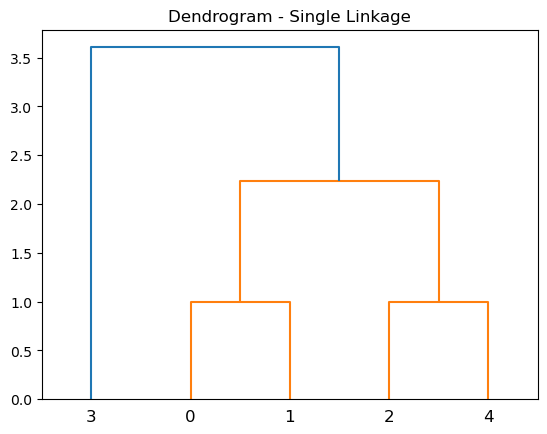

In [1]:
# Single Linkage

import numpy as np
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering

data = np.array([[1,1], [2,1], [3,4], [5,7], [3,3]])

Z = linkage(data, method='single')
plt.figure()
plt.title('Dendrogram - Single Linkage')
dendrogram(Z)
plt.show()

model = AgglomerativeClustering(n_clusters=3, linkage='single')
labels = model.fit_predict(data)

In [12]:
# Single linkage manual
import numpy as np

data = np.array([[1,1], [2,1], [3,4], [5,7], [3,3]])

def euclidean(a, b):
    return np.linalg.norm(a-b)

def single_linkage(clusters):
    min_dist = float('inf')
    pair = None
    for i in range(len(clusters)):
        for j in range(i+1, len(clusters)):
            d = min(euclidean(p1, p2) for p1 in clusters[i] for p2 in clusters[j])
            if d < min_dist:
                min_dist = d
                pair = (i,j)
    return pair

def agglomerative_single(data, n_clusters=3):
    clusters = [[point] for point in data]
    while len(clusters) > n_clusters:
        i,j = single_linkage(clusters)
        clusters.append(clusters[i] + clusters[j])
        clusters.pop(max(i,j))
        clusters.pop(min(i,j))
    labels = np.zeros(len(data), dtype=int)
    for idx, cluster in enumerate(clusters):
        for point in cluster:
            for original_idx, original_point in enumerate(data):
                if np.array_equal(point, original_point):
                    labels[original_idx] = idx
    return labels

labels = agglomerative_single(data)
print("Clusters with single linkage (manual):", labels)

Clusters with single linkage (manual): [1 1 2 0 2]


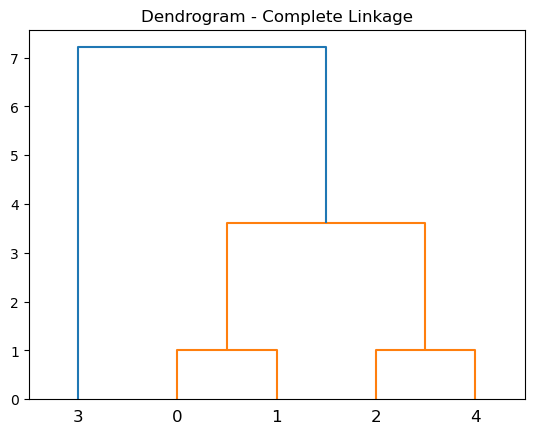

Clusters with complete linkage (built-in): [0 0 0 1 0]


In [6]:
# Complete Linkage

import numpy as np
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering

data = np.array([[1,1], [2,1], [3,4], [5,7], [3,3]])

Z = linkage(data, method='complete')
plt.figure()
plt.title('Dendrogram - Complete Linkage')
dendrogram(Z)
plt.show()

model = AgglomerativeClustering(n_clusters=2, linkage='complete')
labels = model.fit_predict(data)

In [7]:
# Complete Linbkage Manaul

import numpy as np

data = np.array([[1,1], [2,1], [3,4], [5,7], [3,3]])

def euclidean(a, b):
    return np.linalg.norm(a-b)

def complete_linkage(clusters):
    max_dist = -float('inf')
    pair = None
    for i in range(len(clusters)):
        for j in range(i+1, len(clusters)):
            d = max(euclidean(p1, p2) for p1 in clusters[i] for p2 in clusters[j])
            if d > max_dist:
                max_dist = d
                pair = (i,j)
    return pair

def agglomerative_complete(data, n_clusters=2):
    clusters = [[point] for point in data]
    while len(clusters) > n_clusters:
        i,j = complete_linkage(clusters)
        clusters.append(clusters[i] + clusters[j])
        clusters.pop(max(i,j))
        clusters.pop(min(i,j))
    labels = np.zeros(len(data), dtype=int)
    for idx, cluster in enumerate(clusters):
        for point in cluster:
            for original_idx, original_point in enumerate(data):
                if np.array_equal(point, original_point):
                    labels[original_idx] = idx
    return labels

labels = agglomerative_complete(data)
print("Clusters with complete linkage (manual):", labels)


Clusters with complete linkage (manual): [1 1 0 1 1]


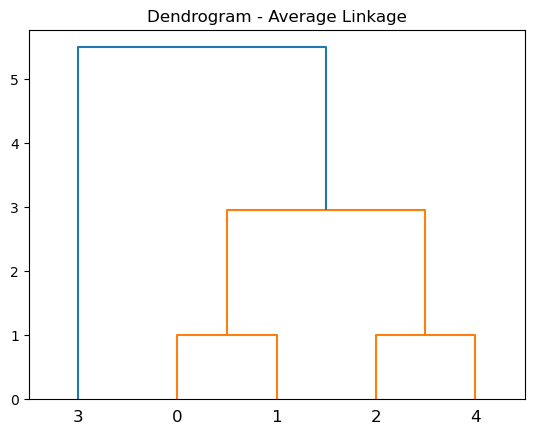

Clusters with average linkage (built-in): [0 0 0 1 0]


In [8]:
# Average Linkage

import numpy as np
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering

data = np.array([[1,1], [2,1], [3,4], [5,7], [3,3]])

Z = linkage(data, method='average')
plt.figure()
plt.title('Dendrogram - Average Linkage')
dendrogram(Z)
plt.show()

model = AgglomerativeClustering(n_clusters=2, linkage='average')
labels = model.fit_predict(data)

In [9]:
# Average Linkage Manual

import numpy as np

data = np.array([[1,1], [2,1], [3,4], [5,7], [3,3]])

def euclidean(a, b):
    return np.linalg.norm(a-b)

def average_linkage(clusters):
    min_avg = float('inf')
    pair = None
    for i in range(len(clusters)):
        for j in range(i+1, len(clusters)):
            distances = [euclidean(p1, p2) for p1 in clusters[i] for p2 in clusters[j]]
            avg_dist = sum(distances) / len(distances)
            if avg_dist < min_avg:
                min_avg = avg_dist
                pair = (i,j)
    return pair

def agglomerative_average(data, n_clusters=2):
    clusters = [[point] for point in data]
    while len(clusters) > n_clusters:
        i,j = average_linkage(clusters)
        clusters.append(clusters[i] + clusters[j])
        clusters.pop(max(i,j))
        clusters.pop(min(i,j))
    labels = np.zeros(len(data), dtype=int)
    for idx, cluster in enumerate(clusters):
        for point in cluster:
            for original_idx, original_point in enumerate(data):
                if np.array_equal(point, original_point):
                    labels[original_idx] = idx
    return labels

labels = agglomerative_average(data)
print("Clusters with average linkage (manual):", labels)


Clusters with average linkage (manual): [1 1 1 0 1]


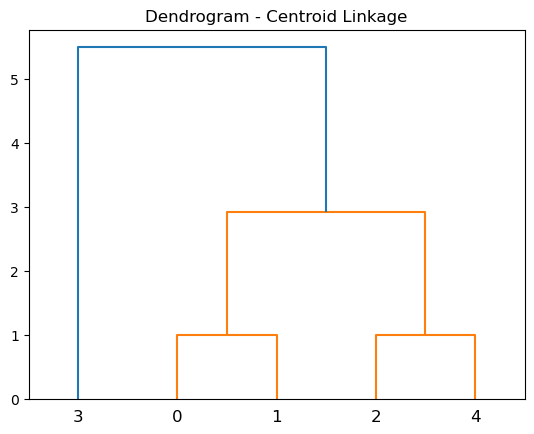

In [2]:
# Cerntroid Linkage

import numpy as np
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

data = np.array([[1,1], [2,1], [3,4], [5,7], [3,3]])

Z = linkage(data, method='centroid')
plt.figure()
plt.title('Dendrogram - Centroid Linkage')
dendrogram(Z)
plt.show()


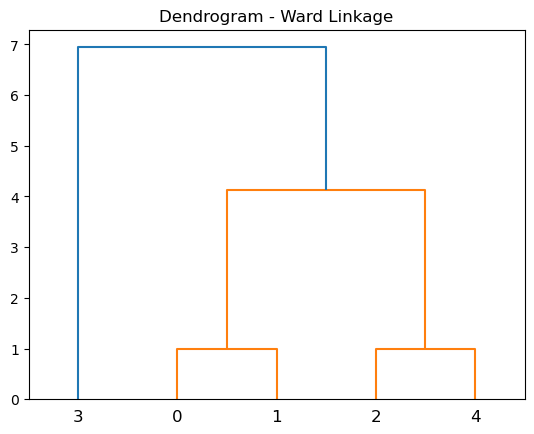

In [4]:
# Ward Linkage

import numpy as np
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering

data = np.array([[1,1], [2,1], [3,4], [5,7], [3,3]])

Z = linkage(data, method='ward')
plt.figure()
plt.title('Dendrogram - Ward Linkage')
dendrogram(Z)
plt.show()

model = AgglomerativeClustering(n_clusters=2, linkage='ward')
labels = model.fit_predict(data)